In [1]:
#FLOW OF PRACTICAL 7

#1. Import NLP libraries
#2. Input text
#3. Tokenization
#4. Stopword removal
#5. POS tagging
#6. Stemming
#7. Lemmatization
#8. TF-IDF calculation
#9. Visualization

In [6]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

from sklearn.feature_extraction.text import TfidfVectorizer

In [11]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\khoba\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\khoba\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [12]:
from nltk.tokenize import word_tokenize

tokens = word_tokenize(text)

print(tokens)

['Data', 'Science', 'is', 'an', 'interdisciplinary', 'field', 'that', 'uses', 'scientific', 'methods', ',', 'processes', ',', 'algorithms', 'and', 'systems', 'to', 'extract', 'knowledge', 'from', 'data', '.']


In [16]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\khoba\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\khoba\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\khoba\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\khoba\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\khoba\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


True

In [8]:
text = """
Data Science is an interdisciplinary field that uses scientific methods,
processes, algorithms and systems to extract knowledge from data.
"""

In [13]:
tokens = word_tokenize(text)

print(tokens)

['Data', 'Science', 'is', 'an', 'interdisciplinary', 'field', 'that', 'uses', 'scientific', 'methods', ',', 'processes', ',', 'algorithms', 'and', 'systems', 'to', 'extract', 'knowledge', 'from', 'data', '.']


In [14]:
stop_words = set(stopwords.words('english'))

filtered_words = [
    word for word in tokens
    if word.lower() not in stop_words
]

print(filtered_words)

['Data', 'Science', 'interdisciplinary', 'field', 'uses', 'scientific', 'methods', ',', 'processes', ',', 'algorithms', 'systems', 'extract', 'knowledge', 'data', '.']


In [17]:
pos = pos_tag(filtered_words)

print(pos)

[('Data', 'NNP'), ('Science', 'NNP'), ('interdisciplinary', 'JJ'), ('field', 'NN'), ('uses', 'VBZ'), ('scientific', 'JJ'), ('methods', 'NNS'), (',', ','), ('processes', 'NNS'), (',', ','), ('algorithms', 'JJ'), ('systems', 'NNS'), ('extract', 'JJ'), ('knowledge', 'NNP'), ('data', 'NN'), ('.', '.')]


In [18]:
ps = PorterStemmer()

stemmed_words = [
    ps.stem(word)
    for word in filtered_words
]

print(stemmed_words)

['data', 'scienc', 'interdisciplinari', 'field', 'use', 'scientif', 'method', ',', 'process', ',', 'algorithm', 'system', 'extract', 'knowledg', 'data', '.']


In [19]:
lemmatizer = WordNetLemmatizer()

lemmatized_words = [
    lemmatizer.lemmatize(word)
    for word in filtered_words
]

print(lemmatized_words)

['Data', 'Science', 'interdisciplinary', 'field', 'us', 'scientific', 'method', ',', 'process', ',', 'algorithm', 'system', 'extract', 'knowledge', 'data', '.']


In [20]:
documents = [text]

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(documents)

print(vectorizer.get_feature_names_out())

print(X.toarray())

['algorithms' 'an' 'and' 'data' 'extract' 'field' 'from'
 'interdisciplinary' 'is' 'knowledge' 'methods' 'processes' 'science'
 'scientific' 'systems' 'that' 'to' 'uses']
[[0.21821789 0.21821789 0.21821789 0.43643578 0.21821789 0.21821789
  0.21821789 0.21821789 0.21821789 0.21821789 0.21821789 0.21821789
  0.21821789 0.21821789 0.21821789 0.21821789 0.21821789 0.21821789]]


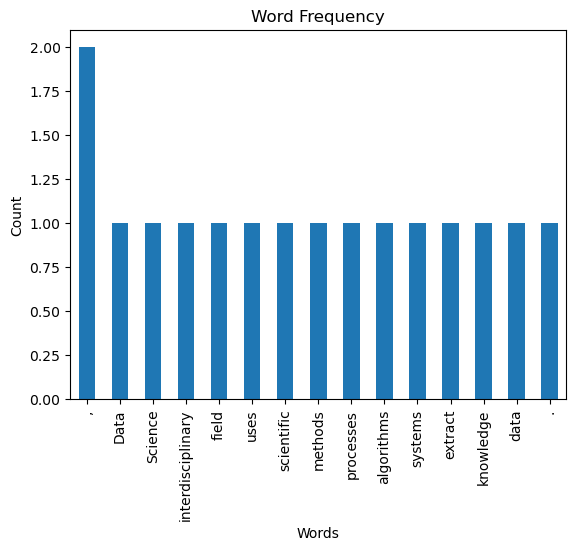

In [21]:
freq = pd.Series(filtered_words).value_counts()

freq.plot(kind='bar')

plt.title("Word Frequency")

plt.xlabel("Words")
plt.ylabel("Count")

plt.show()